#Task 2: Experimentation and uplift testing

###Julia has asked us to evaluate the performance of a store trial which was performed in stores 77, 86 and 88

##Main Analysis Task
* Define key metrics: sales, customers, transactions per customer

* Use pre-trial data to find similar control stores

* Measure similarity using correlation and distance metrics

* Select best control store for each trial store

* Compare trial vs control during trial period

* Test if sales difference is significant

* Identify drivers of change (customers vs transactions)

* Draw conclusion and recommendation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/QVI_data.csv')
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [ ]:
df.tail()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget
264833,2373711,2018-12-14,88,241815,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4,330,SMITHS,YOUNG SINGLES/COUPLES,Mainstream


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [ ]:
df.shape

(264834, 12)

In [ ]:
df.isnull().sum()

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

Convert the 'DATE' column in the `df` DataFrame to a datetime format and then display the first few rows of the DataFrame to confirm the change.


Identify the column containing date or month-year information that needs reformatting.


In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


Create a 'YEARMONTH' column in the `df` DataFrame by extracting the year and month from the 'DATE' column, then aggregate the data by 'STORE_NBR' and 'YEARMONTH' to calculate 'total_sales', 'total_customers', and 'total_transactions', and finally calculate 'transactions_per_customer' within each group.

In [ ]:
df['YEARMONTH'] = df['DATE'].dt.to_period('M')

grouped_df = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    total_sales=('TOT_SALES', 'sum'),
    total_customers=('LYLTY_CARD_NBR', 'nunique'),
    total_transactions=('TXN_ID', 'nunique')
).reset_index()

grouped_df['transactions_per_customer'] = grouped_df['total_transactions'] / grouped_df['total_customers']

print("First 5 rows of grouped_df:")
print(grouped_df.head())
print("\nInfo of grouped_df:")
grouped_df.info()

First 5 rows of grouped_df:
   STORE_NBR YEARMONTH  total_sales  total_customers  total_transactions  \
0          1   2018-07        206.9               49                  52   
1          1   2018-08        176.1               42                  43   
2          1   2018-09        278.8               59                  62   
3          1   2018-10        188.1               44                  45   
4          1   2018-11        192.6               46                  47   

   transactions_per_customer  
0                   1.061224  
1                   1.023810  
2                   1.050847  
3                   1.022727  
4                   1.021739  

Info of grouped_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype    
---  ------                     --------------  -----    
 0   STORE_NBR                  3169 non-null   int64    
 1   YEARMONTH              

## Identify Trial and Control Store Candidates




In [ ]:
trial_stores = [77, 86, 88]
pre_trial_end_date = pd.Period('2019-01')

trial_store_data_pre_trial = grouped_df[
    (grouped_df['STORE_NBR'].isin(trial_stores)) &
    (grouped_df['YEARMONTH'] <= pre_trial_end_date)
]

potential_control_store_data_pre_trial = grouped_df[
    (~grouped_df['STORE_NBR'].isin(trial_stores)) &
    (grouped_df['YEARMONTH'] <= pre_trial_end_date)
]

print("First 5 rows of trial_store_data_pre_trial:")
print(trial_store_data_pre_trial.head())
print("\nInfo of trial_store_data_pre_trial:")
trial_store_data_pre_trial.info()

print("\nFirst 5 rows of potential_control_store_data_pre_trial:")
print(potential_control_store_data_pre_trial.head())
print("\nInfo of potential_control_store_data_pre_trial:")
potential_control_store_data_pre_trial.info()

First 5 rows of trial_store_data_pre_trial:
     STORE_NBR YEARMONTH  total_sales  total_customers  total_transactions  \
880         77   2018-07        296.8               51                  55   
881         77   2018-08        255.5               47                  48   
882         77   2018-09        225.2               42                  44   
883         77   2018-10        204.5               37                  38   
884         77   2018-11        245.3               41                  44   

     transactions_per_customer  
880                   1.078431  
881                   1.021277  
882                   1.047619  
883                   1.027027  
884                   1.073171  

Info of trial_store_data_pre_trial:
<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 880 to 1007
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype    
---  ------                     --------------  -----    
 0   STORE_NBR                  21 

## Implement Control Store Selection Function




To implement the control store selection function, I will define the `find_control_store` function as specified in the subtask. This function will take a trial store number and the pre-trial aggregated DataFrame (`grouped_df` filtered for the pre-trial period) as input. It will then iterate through potential control stores, calculate Pearson correlations and absolute percentage differences for key metrics, combine these into a composite similarity score, and return the store number with the highest score.



In [ ]:
pre_trial_grouped_df_all = grouped_df[grouped_df['YEARMONTH'] <= pre_trial_end_date].copy()

def find_control_store(trial_store_num, pre_trial_data_for_all_stores):
    """
    Finds the most similar control store for a given trial store based on pre-trial data.

    Args:
        trial_store_num (int): The store number of the trial store.
        pre_trial_data_for_all_stores (pd.DataFrame): DataFrame containing aggregated monthly data
                                                      for all stores during the pre-trial period,
                                                      including 'STORE_NBR', 'YEARMONTH',
                                                      'total_sales', 'total_customers',
                                                      and 'transactions_per_customer'.

    Returns:
        int: The store number of the most similar control store, or None if no suitable
             control store is found.
    """
    # 1. Filter trial store data from the combined pre-trial data
    trial_store_data = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] == trial_store_num]

    if trial_store_data.empty:
        print(f"No pre-trial data found for trial store {trial_store_num} in the provided grouped_df.")
        return None

    # 2. Identify potential control stores (all other stores in the pre_trial_grouped_df)
    potential_control_stores_df = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] != trial_store_num].copy()
    unique_control_store_nums = potential_control_stores_df['STORE_NBR'].unique()

    # 3. Initialize list to store similarity scores
    similarity_scores = []

    # Calculate average metrics for the trial store (these remain constant for comparisons)
    avg_sales_trial = trial_store_data['total_sales'].mean()
    avg_customers_trial = trial_store_data['total_customers'].mean()
    avg_tpc_trial = trial_store_data['transactions_per_customer'].mean()

    # Basic check for non-zero averages for trial store to avoid division by zero
    if avg_sales_trial <= 0 or avg_customers_trial <= 0 or avg_tpc_trial <= 0:
        print(f"Warning: Trial store {trial_store_num} has zero or negative average for some metrics in pre-trial. Cannot calculate percentage difference accurately.")
        return None

    # 4. Iterate through each unique potential control store
    for control_store_candidate_num in unique_control_store_nums:
        control_store_data = potential_control_stores_df[potential_control_stores_df['STORE_NBR'] == control_store_candidate_num]

        # Ensure control store has data for the pre-trial period
        if control_store_data.empty:
            continue

        # b. Align the data for the trial store and the potential control store by 'YEARMONTH'
        merged_data = pd.merge(trial_store_data, control_store_data, on='YEARMONTH', suffixes=('_trial', '_control'))

        # We need at least 2 common time points to calculate a meaningful correlation.
        # If not enough common data points, skip this control store.
        if len(merged_data) < 2:
            continue

        # c. Calculate Pearson correlation for specified metrics
        corr_sales = merged_data['total_sales_trial'].corr(merged_data['total_sales_control'])
        corr_customers = merged_data['total_customers_trial'].corr(merged_data['total_customers_control'])
        corr_tpc = merged_data['transactions_per_customer_trial'].corr(merged_data['transactions_per_customer_control'])

        # Handle NaN correlations (e.g., if one series is constant, std dev is 0). Replace with 0.
        corr_sales = 0.0 if pd.isna(corr_sales) else corr_sales
        corr_customers = 0.0 if pd.isna(corr_customers) else corr_customers
        corr_tpc = 0.0 if pd.isna(corr_tpc) else corr_tpc

        # d. Calculate magnitude distance metric (absolute percentage difference of means)
        avg_sales_control = control_store_data['total_sales'].mean()
        avg_customers_control = control_store_data['total_customers'].mean()
        avg_tpc_control = control_store_data['transactions_per_customer'].mean()

        mag_diff_sales = abs(avg_sales_trial - avg_sales_control) / avg_sales_trial
        mag_diff_customers = abs(avg_customers_trial - avg_customers_control) / avg_customers_trial
        mag_diff_tpc = abs(avg_tpc_trial - avg_tpc_control) / avg_tpc_trial

        # e. Combine these metrics into a single similarity score
        # Higher correlation is better, lower magnitude difference is better.
        # Average of correlations minus sum of magnitude percentage differences.
        total_correlation_component = (corr_sales + corr_customers + corr_tpc) / 3
        total_magnitude_diff_component = mag_diff_sales + mag_diff_customers + mag_diff_tpc

        composite_score = total_correlation_component - total_magnitude_diff_component

        # f. Store the potential control store number and its similarity score
        similarity_scores.append((control_store_candidate_num, composite_score))

    # 6. After iterating, identify the store with the highest similarity score
    if not similarity_scores:
        print(f"No suitable control store found with enough common data points for trial store {trial_store_num}.")
        return None

    best_control_store_num = max(similarity_scores, key=lambda item: item[1])[0]

    # 7. Return the store number of the most similar control store
    return best_control_store_num

print("The 'find_control_store' function has been defined.")

The 'find_control_store' function has been defined.



Now that the `find_control_store` function is defined, I will use it to identify the best control store for each of the trial stores. I will iterate through the `trial_stores` list, apply the function, and store the mappings in a dictionary.



In [ ]:
control_stores_map = {}
for trial_store in trial_stores:
    best_control = find_control_store(trial_store, pre_trial_grouped_df_all)
    if best_control is not None:
        control_stores_map[trial_store] = best_control
    else:
        print(f"Could not find a suitable control store for trial store {trial_store}")

print("Mapping of trial stores to their best control stores:")
print(control_stores_map)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:292

Mapping of trial stores to their best control stores:
{77: np.int64(233), 86: np.int64(138), 88: np.int64(201)}


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:292

**Reasoning**:
The previous code generated `RuntimeWarning: invalid value encountered in divide` during correlation calculations because `corr()` returns `NaN` when a series has a standard deviation of zero. Although the `NaN` values were handled by converting them to `0.0`, it's better practice to prevent the warning by explicitly checking for zero standard deviation before calculating the correlation. I will modify the `find_control_store` function to include this check.



In [ ]:
pre_trial_grouped_df_all = grouped_df[grouped_df['YEARMONTH'] <= pre_trial_end_date].copy()

def find_control_store(trial_store_num, pre_trial_data_for_all_stores):
    """
    Finds the most similar control store for a given trial store based on pre-trial data.

    Args:
        trial_store_num (int): The store number of the trial store.
        pre_trial_data_for_all_stores (pd.DataFrame): DataFrame containing aggregated monthly data
                                                      for all stores during the pre-trial period,
                                                      including 'STORE_NBR', 'YEARMONTH',
                                                      'total_sales', 'total_customers',
                                                      and 'transactions_per_customer'.

    Returns:
        int: The store number of the most similar control store, or None if no suitable
             control store is found.
    """
    # 1. Filter trial store data from the combined pre-trial data
    trial_store_data = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] == trial_store_num]

    if trial_store_data.empty:
        print(f"No pre-trial data found for trial store {trial_store_num} in the provided grouped_df.")
        return None

    # 2. Identify potential control stores (all other stores in the pre_trial_grouped_df)
    potential_control_stores_df = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] != trial_store_num].copy()
    unique_control_store_nums = potential_control_stores_df['STORE_NBR'].unique()

    # 3. Initialize list to store similarity scores
    similarity_scores = []

    # Calculate average metrics for the trial store (these remain constant for comparisons)
    avg_sales_trial = trial_store_data['total_sales'].mean()
    avg_customers_trial = trial_store_data['total_customers'].mean()
    avg_tpc_trial = trial_store_data['transactions_per_customer'].mean()

    # Basic check for non-zero averages for trial store to avoid division by zero
    if avg_sales_trial <= 0 or avg_customers_trial <= 0 or avg_tpc_trial <= 0:
        print(f"Warning: Trial store {trial_store_num} has zero or negative average for some metrics in pre-trial. Cannot calculate percentage difference accurately.")
        return None

    # 4. Iterate through each unique potential control store
    for control_store_candidate_num in unique_control_store_nums:
        control_store_data = potential_control_stores_df[potential_control_stores_df['STORE_NBR'] == control_store_candidate_num]

        # Ensure control store has data for the pre-trial period
        if control_store_data.empty:
            continue

        # b. Align the data for the trial store and the potential control store by 'YEARMONTH'
        merged_data = pd.merge(trial_store_data, control_store_data, on='YEARMONTH', suffixes=('_trial', '_control'))

        # We need at least 2 common time points to calculate a meaningful correlation.
        # If not enough common data points, skip this control store.
        if len(merged_data) < 2:
            continue

        # c. Calculate Pearson correlation for specified metrics
        # Handle cases where std dev is 0 for correlation calculation to avoid RuntimeWarning
        corr_sales = 0.0
        if merged_data['total_sales_trial'].std() != 0 and merged_data['total_sales_control'].std() != 0:
            corr_sales = merged_data['total_sales_trial'].corr(merged_data['total_sales_control'])
        corr_sales = 0.0 if pd.isna(corr_sales) else corr_sales

        corr_customers = 0.0
        if merged_data['total_customers_trial'].std() != 0 and merged_data['total_customers_control'].std() != 0:
            corr_customers = merged_data['total_customers_trial'].corr(merged_data['total_customers_control'])
        corr_customers = 0.0 if pd.isna(corr_customers) else corr_customers

        corr_tpc = 0.0
        if merged_data['transactions_per_customer_trial'].std() != 0 and merged_data['transactions_per_customer_control'].std() != 0:
            corr_tpc = merged_data['transactions_per_customer_trial'].corr(merged_data['transactions_per_customer_control'])
        corr_tpc = 0.0 if pd.isna(corr_tpc) else corr_tpc

        # d. Calculate magnitude distance metric (absolute percentage difference of means)
        avg_sales_control = control_store_data['total_sales'].mean()
        avg_customers_control = control_store_data['total_customers'].mean()
        avg_tpc_control = control_store_data['transactions_per_customer'].mean()

        # Ensure control store averages are not zero to avoid division by zero in magnitude differences
        # If a control store has zero for an average metric, it's not a good comparison for percentage diff
        if avg_sales_control <= 0 or avg_customers_control <= 0 or avg_tpc_control <= 0:
            # Assign a very low score to effectively skip this control store for a positive trial
            composite_score = -np.inf
        else:
            mag_diff_sales = abs(avg_sales_trial - avg_sales_control) / avg_sales_trial
            mag_diff_customers = abs(avg_customers_trial - avg_customers_control) / avg_customers_trial
            mag_diff_tpc = abs(avg_tpc_trial - avg_tpc_control) / avg_tpc_trial

            # e. Combine these metrics into a single similarity score
            # Higher correlation is better, lower magnitude difference is better.
            # Average of correlations minus sum of magnitude percentage differences.
            total_correlation_component = (corr_sales + corr_customers + corr_tpc) / 3
            total_magnitude_diff_component = mag_diff_sales + mag_diff_customers + mag_diff_tpc

            composite_score = total_correlation_component - total_magnitude_diff_component

        # f. Store the potential control store number and its similarity score
        similarity_scores.append((control_store_candidate_num, composite_score))

    # 6. After iterating, identify the store with the highest similarity score
    if not similarity_scores:
        print(f"No suitable control store found with enough common data points for trial store {trial_store_num}.")
        return None

    best_control_store_num = max(similarity_scores, key=lambda item: item[1])[0]

    # 7. Return the store number of the most similar control store
    return best_control_store_num

print("The 'find_control_store' function has been defined.")

The 'find_control_store' function has been defined.



The `find_control_store` function has been updated to prevent `RuntimeWarning`s during correlation calculations. Now, I will re-execute the logic to map trial stores to their best control stores using this improved function. This will ensure that the control stores are selected based on the most robust similarity calculations.



In [ ]:
control_stores_map = {}
for trial_store in trial_stores:
    best_control = find_control_store(trial_store, pre_trial_grouped_df_all)
    if best_control is not None:
        control_stores_map[trial_store] = best_control
    else:
        print(f"Could not find a suitable control store for trial store {trial_store}")

print("Mapping of trial stores to their best control stores:")
print(control_stores_map)

Mapping of trial stores to their best control stores:
{77: np.int64(233), 86: np.int64(138), 88: np.int64(201)}


## Prepare Data for Trial-Control Comparisons

### Subtask:
For each identified trial-control pair, create a combined DataFrame covering the entire analysis period (e.g., July 2018 to April 2019). Ensure the 'YEARMONTH' column is in datetime format for accurate chronological plotting, and clearly define the 'trial_start_date' and 'trial_end_date' for highlighting the trial period in visualizations.


**Reasoning**:
I will define the trial period, initialize a dictionary, and then iterate through the trial-control pairs identified earlier. For each pair, I will filter the `grouped_df`, combine the trial and control store data, add a 'Store_Type' column, convert 'YEARMONTH' to datetime, and store the result in a new dictionary. Finally, I will display a sample combined DataFrame to verify the output.



In [ ]:
trial_start_date = pd.Period('2019-02')
trial_end_date = pd.Period('2019-04')

trial_control_data = {}

for trial_store, control_store in control_stores_map.items():
    # Filter data for the trial store
    trial_store_df = grouped_df[grouped_df['STORE_NBR'] == trial_store].copy()
    trial_store_df['Store_Type'] = 'Trial'

    # Filter data for the control store
    control_store_df = grouped_df[grouped_df['STORE_NBR'] == control_store].copy()
    control_store_df['Store_Type'] = 'Control'

    # Concatenate the dataframes
    combined_df = pd.concat([trial_store_df, control_store_df], ignore_index=True)

    # Convert YEARMONTH to datetime object for plotting
    combined_df['YEARMONTH'] = combined_df['YEARMONTH'].dt.to_timestamp()

    # Store the combined DataFrame
    trial_control_data[trial_store] = combined_df

# Verify the structure for one of the combined dataframes, e.g., for trial store 77
print(f"Combined DataFrame for Trial Store 77 (Head):\n{trial_control_data[77].head()}")
print(f"\nCombined DataFrame for Trial Store 77 (Info):")
trial_control_data[77].info()

Combined DataFrame for Trial Store 77 (Head):
   STORE_NBR  YEARMONTH  total_sales  total_customers  total_transactions  \
0         77 2018-07-01        296.8               51                  55   
1         77 2018-08-01        255.5               47                  48   
2         77 2018-09-01        225.2               42                  44   
3         77 2018-10-01        204.5               37                  38   
4         77 2018-11-01        245.3               41                  44   

   transactions_per_customer Store_Type  
0                   1.078431      Trial  
1                   1.021277      Trial  
2                   1.047619      Trial  
3                   1.027027      Trial  
4                   1.073171      Trial  

Combined DataFrame for Trial Store 77 (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                


I will visualize the total sales for each trial store and its selected control store over time. This will involve plotting the 'total_sales' from the combined DataFrames, distinguishing between trial and control stores, and marking the pre-trial and trial periods to visually assess the impact of the trial. This aligns with the main task of comparing trial vs. control during the trial period.



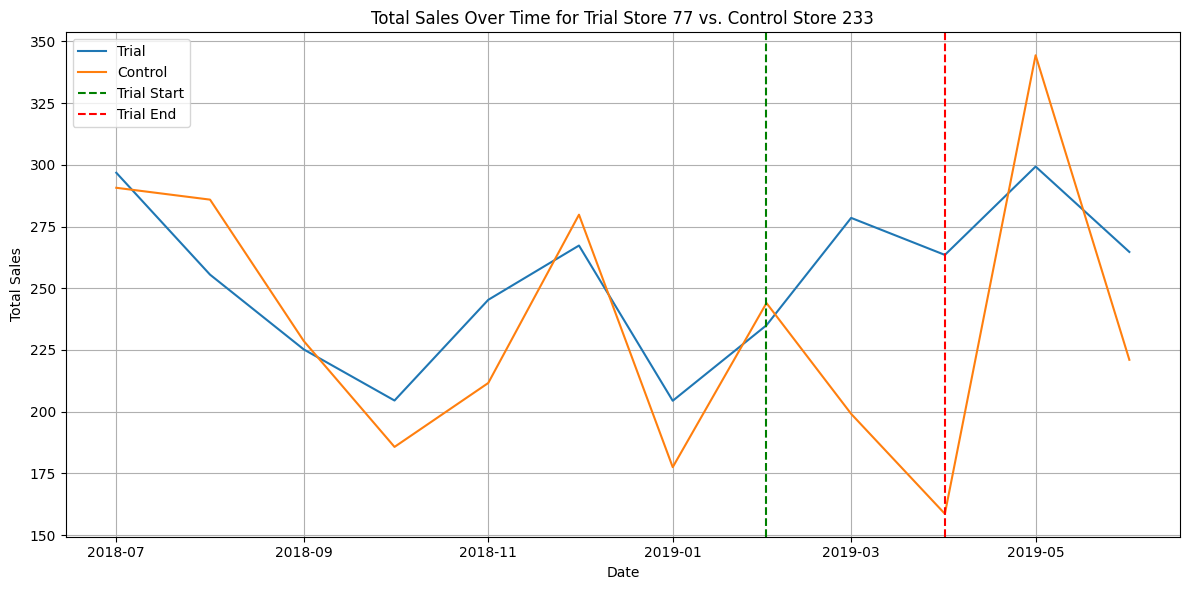

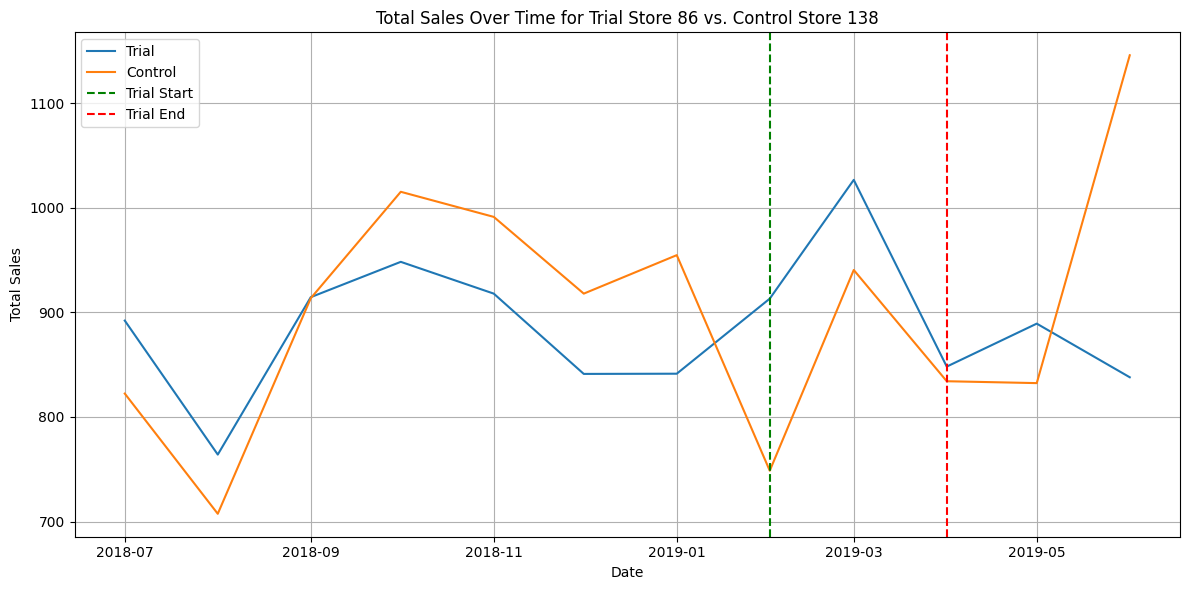

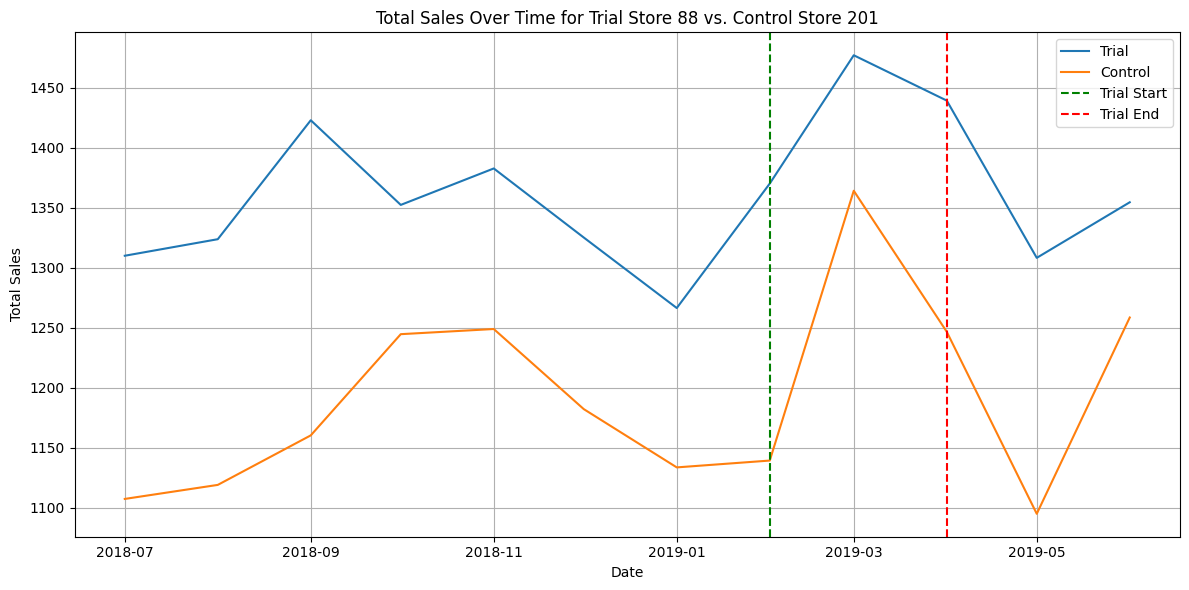

In [ ]:
for trial_store_num, combined_df in trial_control_data.items():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined_df, x='YEARMONTH', y='total_sales', hue='Store_Type')

    # Add vertical lines for trial period
    plt.axvline(x=trial_start_date.to_timestamp(), color='green', linestyle='--', label='Trial Start')
    plt.axvline(x=trial_end_date.to_timestamp(), color='red', linestyle='--', label='Trial End')

    plt.title(f'Total Sales Over Time for Trial Store {trial_store_num} vs. Control Store {control_stores_map[trial_store_num]}')
    plt.xlabel('Date')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Visualize Sales Percentage Difference During Trial


Calculate the percentage difference in 'total_sales' between each trial store and its corresponding control store during the trial period. Present these calculated differences in a clear bar chart, illustrating the sales uplift or decline for each trial in an easy-to-understand format.


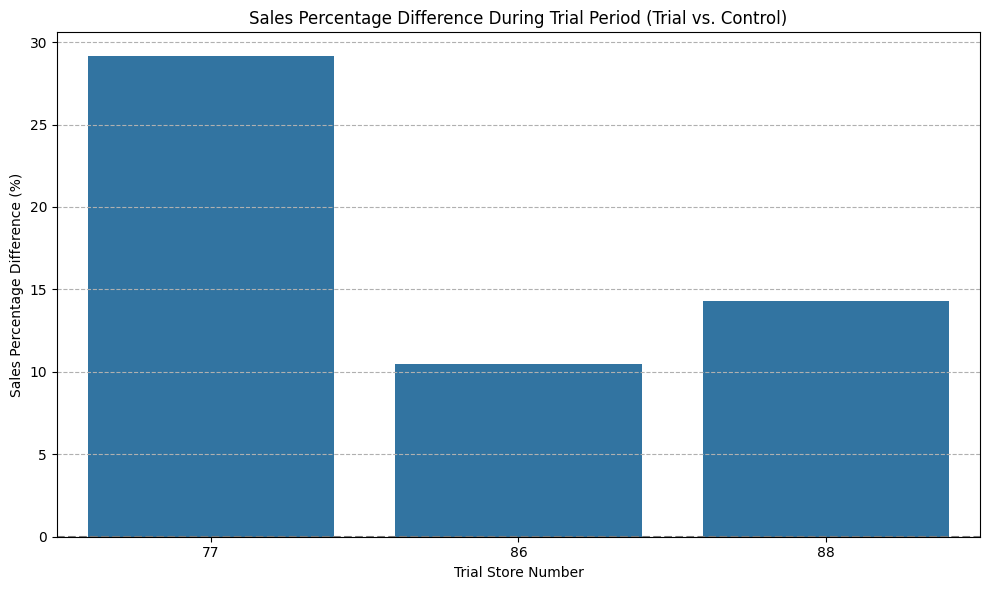

Sales percentage differences during the trial period:
   Trial_Store  Sales_Percentage_Difference
0           77                    29.134120
1           86                    10.493778
2           88                    14.314667


In [ ]:
sales_perc_diff = {}

for trial_store_num, combined_df in trial_control_data.items():
    # Filter data for the trial period
    trial_period_data = combined_df[
        (combined_df['YEARMONTH'] >= trial_start_date.to_timestamp()) &
        (combined_df['YEARMONTH'] <= trial_end_date.to_timestamp())
    ]

    # Separate into trial and control sales data
    trial_sales_data = trial_period_data[trial_period_data['Store_Type'] == 'Trial']
    control_sales_data = trial_period_data[trial_period_data['Store_Type'] == 'Control']

    # Calculate sum of sales for trial and control during the trial period
    trial_sales_sum = trial_sales_data['total_sales'].sum()
    control_sales_sum = control_sales_data['total_sales'].sum()

    # Calculate percentage difference
    if control_sales_sum != 0:
        percentage_difference = ((trial_sales_sum - control_sales_sum) / control_sales_sum) * 100
    else:
        percentage_difference = np.nan # Handle division by zero if control sales are zero

    sales_perc_diff[trial_store_num] = percentage_difference

# Convert the dictionary to a DataFrame for plotting
sales_diff_df = pd.DataFrame(sales_perc_diff.items(), columns=['Trial_Store', 'Sales_Percentage_Difference'])

# Plotting the sales percentage difference
plt.figure(figsize=(10, 6))
sns.barplot(x='Trial_Store', y='Sales_Percentage_Difference', data=sales_diff_df)
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.title('Sales Percentage Difference During Trial Period (Trial vs. Control)')
plt.xlabel('Trial Store Number')
plt.ylabel('Sales Percentage Difference (%)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Sales percentage differences during the trial period:")
print(sales_diff_df)

## Visualize Monthly Total Customers Trends
Generate three line plots, one for each trial-control pair, displaying the monthly 'total_customers' for both the trial and control store over the entire analysis period. The trial period will be clearly highlighted with a shaded region. Ensure plots have descriptive titles, axis labels, and a clear legend.


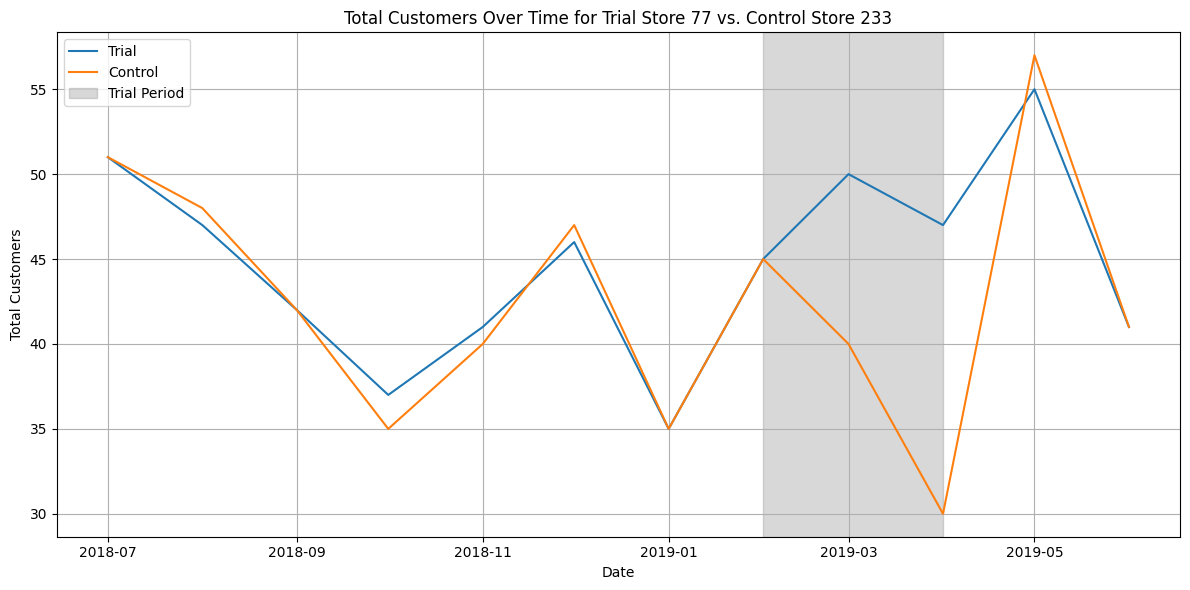

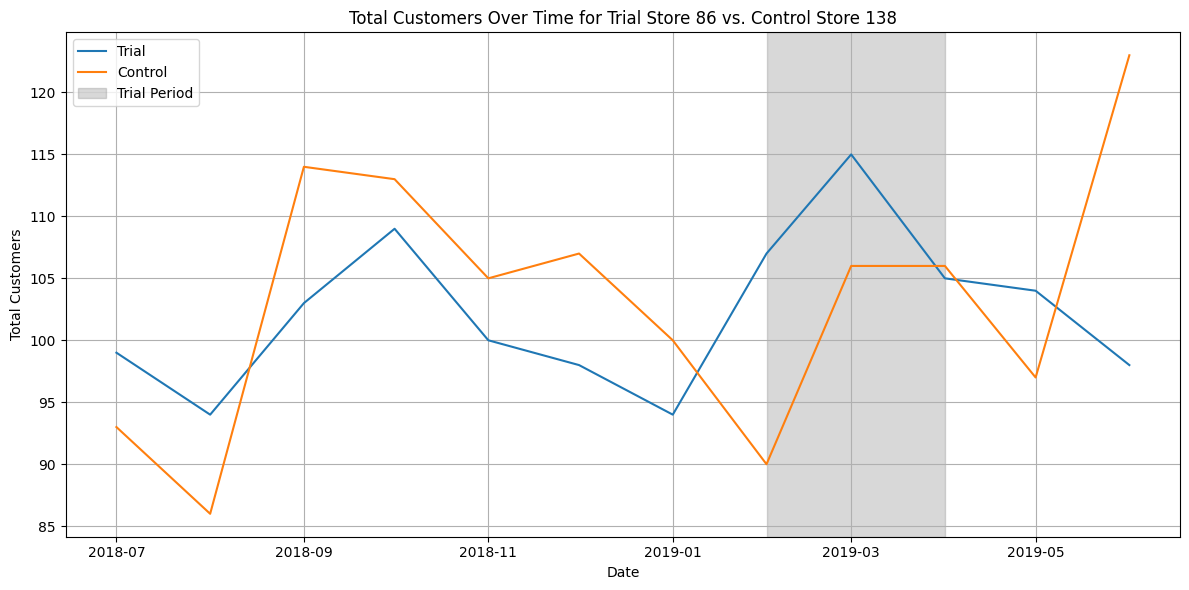

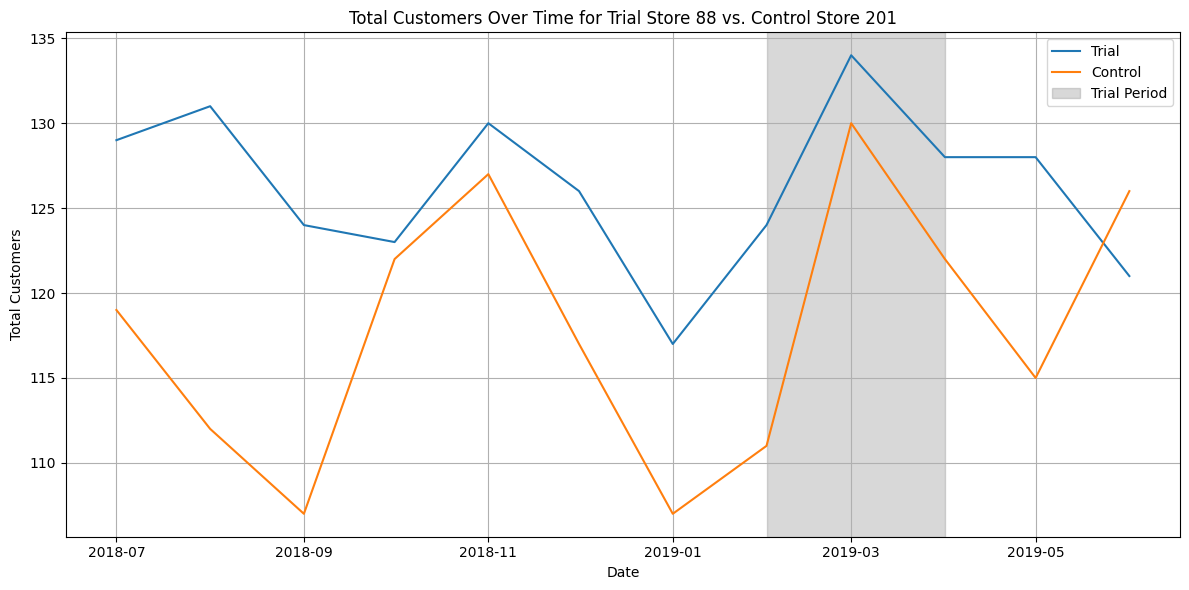

In [ ]:
for trial_store_num, combined_df in trial_control_data.items():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined_df, x='YEARMONTH', y='total_customers', hue='Store_Type')

    # Add shaded region for trial period
    plt.axvspan(trial_start_date.to_timestamp(), trial_end_date.to_timestamp(), color='grey', alpha=0.3, label='Trial Period')

    plt.title(f'Total Customers Over Time for Trial Store {trial_store_num} vs. Control Store {control_stores_map[trial_store_num]}')
    plt.xlabel('Date')
    plt.ylabel('Total Customers')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Visualize Customers Percentage Difference During Trial
Calculate the percentage difference in 'total_customers' between each trial store and its corresponding control store during the trial period. Present these calculated differences in a bar chart, showing the change in customer count for each trial.


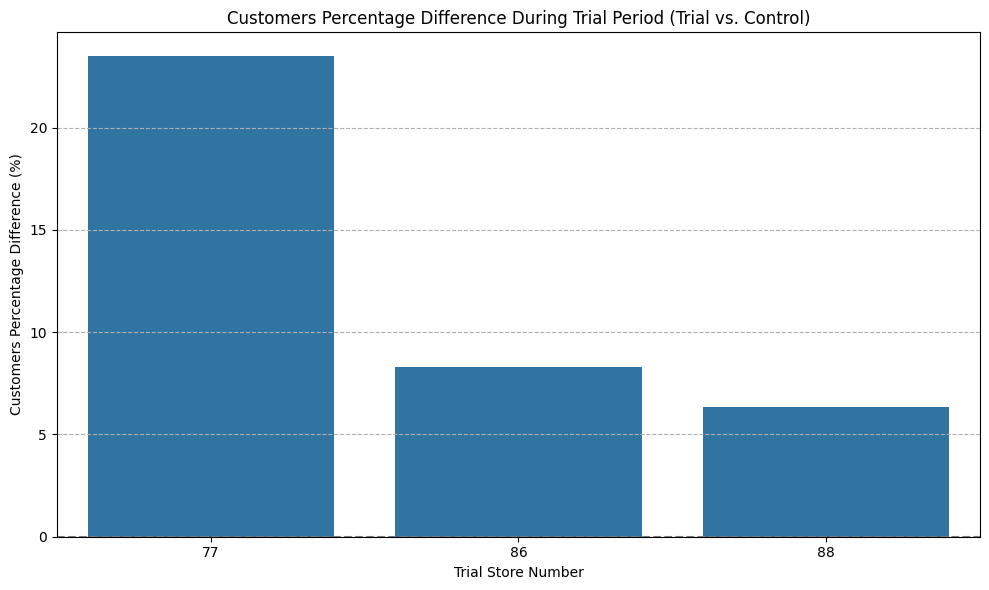

Customers percentage differences during the trial period:
   Trial_Store  Customers_Percentage_Difference
0           77                        23.478261
1           86                         8.278146
2           88                         6.336088


In [ ]:
customers_perc_diff = {}

for trial_store_num, combined_df in trial_control_data.items():
    # Filter data for the trial period
    trial_period_data = combined_df[
        (combined_df['YEARMONTH'] >= trial_start_date.to_timestamp()) &
        (combined_df['YEARMONTH'] <= trial_end_date.to_timestamp())
    ]

    # Separate into trial and control customers data
    trial_customers_data = trial_period_data[trial_period_data['Store_Type'] == 'Trial']
    control_customers_data = trial_period_data[trial_period_data['Store_Type'] == 'Control']

    # Calculate sum of customers for trial and control during the trial periodTask 2: Experimentation and uplift testing
Julia has asked us to evaluate the performance of a store trial which was performed in stores 77, 86 and 88
Main Analysis Task
Define key metrics: sales, customers, transactions per customer

Use pre-trial data to find similar control stores

Measure similarity using correlation and distance metrics

Select best control store for each trial store

Compare trial vs control during trial period

Test if sales difference is significant

Identify drivers of change (customers vs transactions)

Draw conclusion and recommendation


[ ]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

[ ]
from google.colab import drive
drive.mount('/content/drive')
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[ ]
df = pd.read_csv('/QVI_data.csv')
df.head()


[ ]
df.tail()


[ ]
df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   LYLTY_CARD_NBR    264834 non-null  int64
 1   DATE              264834 non-null  object
 2   STORE_NBR         264834 non-null  int64
 3   TXN_ID            264834 non-null  int64
 4   PROD_NBR          264834 non-null  int64
 5   PROD_NAME         264834 non-null  object
 6   PROD_QTY          264834 non-null  int64
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64
 9   BRAND             264834 non-null  object
 10  LIFESTAGE         264834 non-null  object
 11  PREMIUM_CUSTOMER  264834 non-null  object
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB

[ ]
df.shape
(264834, 12)

[ ]
df.isnull().sum()


[ ]
df.duplicated().sum()
np.int64(1)

[ ]
df.drop_duplicates(inplace=True)
df.duplicated().sum()
np.int64(0)

[ ]

Start coding or generate with AI.
Task
The user wants to convert the 'DATE' column in the df DataFrame to a datetime format and then display the first few rows of the DataFrame to confirm the change.

Identify Date Column
Subtask:
Identify the column containing date or month-year information that needs reformatting.


[ ]
df['DATE'] = pd.to_datetime(df['DATE'])
df.head()

Task
Create a 'YEARMONTH' column in the df DataFrame by extracting the year and month from the 'DATE' column, then aggregate the data by 'STORE_NBR' and 'YEARMONTH' to calculate 'total_sales', 'total_customers', and 'total_transactions', and finally calculate 'transactions_per_customer' within each group.

Prepare Aggregated Monthly Data
Subtask:
Create a 'YEARMONTH' column in the df DataFrame by extracting the year and month from the 'DATE' column, then aggregate the data by 'STORE_NBR' and 'YEARMONTH' to calculate 'total_sales', 'total_customers', and 'total_transactions', and finally calculate 'transactions_per_customer' within each group.

Reasoning: To prepare the aggregated monthly data as per the subtask, I will first create a 'YEARMONTH' column, then group the DataFrame by 'STORE_NBR' and 'YEARMONTH' to calculate total sales, total unique customers, and total unique transactions. Finally, I will calculate 'transactions_per_customer' for each group.


[ ]
df['YEARMONTH'] = df['DATE'].dt.to_period('M')

grouped_df = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    total_sales=('TOT_SALES', 'sum'),
    total_customers=('LYLTY_CARD_NBR', 'nunique'),
    total_transactions=('TXN_ID', 'nunique')
).reset_index()

grouped_df['transactions_per_customer'] = grouped_df['total_transactions'] / grouped_df['total_customers']

print("First 5 rows of grouped_df:")
print(grouped_df.head())
print("\nInfo of grouped_df:")
grouped_df.info()
First 5 rows of grouped_df:
   STORE_NBR YEARMONTH  total_sales  total_customers  total_transactions  \
0          1   2018-07        206.9               49                  52
1          1   2018-08        176.1               42                  43
2          1   2018-09        278.8               59                  62
3          1   2018-10        188.1               44                  45
4          1   2018-11        192.6               46                  47

   transactions_per_customer
0                   1.061224
1                   1.023810
2                   1.050847
3                   1.022727
4                   1.021739

Info of grouped_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   STORE_NBR                  3169 non-null   int64
 1   YEARMONTH                  3169 non-null   period[M]
 2   total_sales                3169 non-null   float64
 3   total_customers            3169 non-null   int64
 4   total_transactions         3169 non-null   int64
 5   transactions_per_customer  3169 non-null   float64
dtypes: float64(2), int64(3), period[M](1)
memory usage: 148.7 KB
Identify Trial and Control Store Candidates
Subtask:
Define the trial stores and the pre-trial period, then filter the 'grouped_df' to separate data for trial stores and all other stores (potential control stores) during the pre-trial period.

Reasoning: First, I'll define the trial stores and the pre-trial end date. Then, I will filter the grouped_df to create two separate dataframes: trial_store_data_pre_trial for the trial stores during the pre-trial period and potential_control_store_data_pre_trial for all other stores during the same pre-trial period. Finally, I will display the head and info of both new DataFrames to verify the filtering.


[ ]
trial_stores = [77, 86, 88]
pre_trial_end_date = pd.Period('2019-01')

trial_store_data_pre_trial = grouped_df[
    (grouped_df['STORE_NBR'].isin(trial_stores)) &
    (grouped_df['YEARMONTH'] <= pre_trial_end_date)
]

potential_control_store_data_pre_trial = grouped_df[
    (~grouped_df['STORE_NBR'].isin(trial_stores)) &
    (grouped_df['YEARMONTH'] <= pre_trial_end_date)
]

print("First 5 rows of trial_store_data_pre_trial:")
print(trial_store_data_pre_trial.head())
print("\nInfo of trial_store_data_pre_trial:")
trial_store_data_pre_trial.info()

print("\nFirst 5 rows of potential_control_store_data_pre_trial:")
print(potential_control_store_data_pre_trial.head())
print("\nInfo of potential_control_store_data_pre_trial:")
potential_control_store_data_pre_trial.info()
First 5 rows of trial_store_data_pre_trial:
     STORE_NBR YEARMONTH  total_sales  total_customers  total_transactions  \
880         77   2018-07        296.8               51                  55
881         77   2018-08        255.5               47                  48
882         77   2018-09        225.2               42                  44
883         77   2018-10        204.5               37                  38
884         77   2018-11        245.3               41                  44

     transactions_per_customer
880                   1.078431
881                   1.021277
882                   1.047619
883                   1.027027
884                   1.073171

Info of trial_store_data_pre_trial:
<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 880 to 1007
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   STORE_NBR                  21 non-null     int64
 1   YEARMONTH                  21 non-null     period[M]
 2   total_sales                21 non-null     float64
 3   total_customers            21 non-null     int64
 4   total_transactions         21 non-null     int64
 5   transactions_per_customer  21 non-null     float64
dtypes: float64(2), int64(3), period[M](1)
memory usage: 1.1 KB

First 5 rows of potential_control_store_data_pre_trial:
   STORE_NBR YEARMONTH  total_sales  total_customers  total_transactions  \
0          1   2018-07        206.9               49                  52
1          1   2018-08        176.1               42                  43
2          1   2018-09        278.8               59                  62
3          1   2018-10        188.1               44                  45
4          1   2018-11        192.6               46                  47

   transactions_per_customer
0                   1.061224
1                   1.023810
2                   1.050847
3                   1.022727
4                   1.021739

Info of potential_control_store_data_pre_trial:
<class 'pandas.core.frame.DataFrame'>
Index: 1827 entries, 0 to 3163
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   STORE_NBR                  1827 non-null   int64
 1   YEARMONTH                  1827 non-null   period[M]
 2   total_sales                1827 non-null   float64
 3   total_customers            1827 non-null   int64
 4   total_transactions         1827 non-null   int64
 5   transactions_per_customer  1827 non-null   float64
dtypes: float64(2), int64(3), period[M](1)
memory usage: 99.9 KB
Implement Control Store Selection Function
Subtask:
Create a Python function that takes a trial store number and pre-trial 'grouped_df' as input. The function will calculate similarity measures (e.g., Pearson correlation and a magnitude distance metric for 'total_sales', 'total_customers', and 'transactions_per_customer') between the trial store and all potential control stores during the pre-trial period. It will then combine these measures to identify and return the most similar control store for the given trial store.

Reasoning: To implement the control store selection function, I will define the find_control_store function as specified in the subtask. This function will take a trial store number and the pre-trial aggregated DataFrame (grouped_df filtered for the pre-trial period) as input. It will then iterate through potential control stores, calculate Pearson correlations and absolute percentage differences for key metrics, combine these into a composite similarity score, and return the store number with the highest score.


[ ]
pre_trial_grouped_df_all = grouped_df[grouped_df['YEARMONTH'] <= pre_trial_end_date].copy()

def find_control_store(trial_store_num, pre_trial_data_for_all_stores):
    """
    Finds the most similar control store for a given trial store based on pre-trial data.

    Args:
        trial_store_num (int): The store number of the trial store.
        pre_trial_data_for_all_stores (pd.DataFrame): DataFrame containing aggregated monthly data
                                                      for all stores during the pre-trial period,
                                                      including 'STORE_NBR', 'YEARMONTH',
                                                      'total_sales', 'total_customers',
                                                      and 'transactions_per_customer'.

    Returns:
        int: The store number of the most similar control store, or None if no suitable
             control store is found.
    """
    # 1. Filter trial store data from the combined pre-trial data
    trial_store_data = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] == trial_store_num]

    if trial_store_data.empty:
        print(f"No pre-trial data found for trial store {trial_store_num} in the provided grouped_df.")
        return None

    # 2. Identify potential control stores (all other stores in the pre_trial_grouped_df)
    potential_control_stores_df = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] != trial_store_num].copy()
    unique_control_store_nums = potential_control_stores_df['STORE_NBR'].unique()

    # 3. Initialize list to store similarity scores
    similarity_scores = []

    # Calculate average metrics for the trial store (these remain constant for comparisons)
    avg_sales_trial = trial_store_data['total_sales'].mean()
    avg_customers_trial = trial_store_data['total_customers'].mean()
    avg_tpc_trial = trial_store_data['transactions_per_customer'].mean()

    # Basic check for non-zero averages for trial store to avoid division by zero
    if avg_sales_trial <= 0 or avg_customers_trial <= 0 or avg_tpc_trial <= 0:
        print(f"Warning: Trial store {trial_store_num} has zero or negative average for some metrics in pre-trial. Cannot calculate percentage difference accurately.")
        return None

    # 4. Iterate through each unique potential control store
    for control_store_candidate_num in unique_control_store_nums:
        control_store_data = potential_control_stores_df[potential_control_stores_df['STORE_NBR'] == control_store_candidate_num]

        # Ensure control store has data for the pre-trial period
        if control_store_data.empty:
            continue

        # b. Align the data for the trial store and the potential control store by 'YEARMONTH'
        merged_data = pd.merge(trial_store_data, control_store_data, on='YEARMONTH', suffixes=('_trial', '_control'))

        # We need at least 2 common time points to calculate a meaningful correlation.
        # If not enough common data points, skip this control store.
        if len(merged_data) < 2:
            continue

        # c. Calculate Pearson correlation for specified metrics
        corr_sales = merged_data['total_sales_trial'].corr(merged_data['total_sales_control'])
        corr_customers = merged_data['total_customers_trial'].corr(merged_data['total_customers_control'])
        corr_tpc = merged_data['transactions_per_customer_trial'].corr(merged_data['transactions_per_customer_control'])

        # Handle NaN correlations (e.g., if one series is constant, std dev is 0). Replace with 0.
        corr_sales = 0.0 if pd.isna(corr_sales) else corr_sales
        corr_customers = 0.0 if pd.isna(corr_customers) else corr_customers
        corr_tpc = 0.0 if pd.isna(corr_tpc) else corr_tpc

        # d. Calculate magnitude distance metric (absolute percentage difference of means)
        avg_sales_control = control_store_data['total_sales'].mean()
        avg_customers_control = control_store_data['total_customers'].mean()
        avg_tpc_control = control_store_data['transactions_per_customer'].mean()

        mag_diff_sales = abs(avg_sales_trial - avg_sales_control) / avg_sales_trial
        mag_diff_customers = abs(avg_customers_trial - avg_customers_control) / avg_customers_trial
        mag_diff_tpc = abs(avg_tpc_trial - avg_tpc_control) / avg_tpc_trial

        # e. Combine these metrics into a single similarity score
        # Higher correlation is better, lower magnitude difference is better.
        # Average of correlations minus sum of magnitude percentage differences.
        total_correlation_component = (corr_sales + corr_customers + corr_tpc) / 3
        total_magnitude_diff_component = mag_diff_sales + mag_diff_customers + mag_diff_tpc

        composite_score = total_correlation_component - total_magnitude_diff_component

        # f. Store the potential control store number and its similarity score
        similarity_scores.append((control_store_candidate_num, composite_score))

    # 6. After iterating, identify the store with the highest similarity score
    if not similarity_scores:
        print(f"No suitable control store found with enough common data points for trial store {trial_store_num}.")
        return None

    best_control_store_num = max(similarity_scores, key=lambda item: item[1])[0]

    # 7. Return the store number of the most similar control store
    return best_control_store_num

print("The 'find_control_store' function has been defined.")
The 'find_control_store' function has been defined.
Reasoning: Now that the find_control_store function is defined, I will use it to identify the best control store for each of the trial stores. I will iterate through the trial_stores list, apply the function, and store the mappings in a dictionary.


[ ]
control_stores_map = {}
for trial_store in trial_stores:
    best_control = find_control_store(trial_store, pre_trial_grouped_df_all)
    if best_control is not None:
        control_stores_map[trial_store] = best_control
    else:
        print(f"Could not find a suitable control store for trial store {trial_store}")

print("Mapping of trial stores to their best control stores:")
print(control_stores_map)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Mapping of trial stores to their best control stores:
{77: np.int64(233), 86: np.int64(138), 88: np.int64(201)}
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Reasoning: The previous code generated RuntimeWarning: invalid value encountered in divide during correlation calculations because corr() returns NaN when a series has a standard deviation of zero. Although the NaN values were handled by converting them to 0.0, it's better practice to prevent the warning by explicitly checking for zero standard deviation before calculating the correlation. I will modify the find_control_store function to include this check.


[ ]
pre_trial_grouped_df_all = grouped_df[grouped_df['YEARMONTH'] <= pre_trial_end_date].copy()

def find_control_store(trial_store_num, pre_trial_data_for_all_stores):
    """
    Finds the most similar control store for a given trial store based on pre-trial data.

    Args:
        trial_store_num (int): The store number of the trial store.
        pre_trial_data_for_all_stores (pd.DataFrame): DataFrame containing aggregated monthly data
                                                      for all stores during the pre-trial period,
                                                      including 'STORE_NBR', 'YEARMONTH',
                                                      'total_sales', 'total_customers',
                                                      and 'transactions_per_customer'.

    Returns:
        int: The store number of the most similar control store, or None if no suitable
             control store is found.
    """
    # 1. Filter trial store data from the combined pre-trial data
    trial_store_data = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] == trial_store_num]

    if trial_store_data.empty:
        print(f"No pre-trial data found for trial store {trial_store_num} in the provided grouped_df.")
        return None

    # 2. Identify potential control stores (all other stores in the pre_trial_grouped_df)
    potential_control_stores_df = pre_trial_data_for_all_stores[pre_trial_data_for_all_stores['STORE_NBR'] != trial_store_num].copy()
    unique_control_store_nums = potential_control_stores_df['STORE_NBR'].unique()

    # 3. Initialize list to store similarity scores
    similarity_scores = []

    # Calculate average metrics for the trial store (these remain constant for comparisons)
    avg_sales_trial = trial_store_data['total_sales'].mean()
    avg_customers_trial = trial_store_data['total_customers'].mean()
    avg_tpc_trial = trial_store_data['transactions_per_customer'].mean()

    # Basic check for non-zero averages for trial store to avoid division by zero
    if avg_sales_trial <= 0 or avg_customers_trial <= 0 or avg_tpc_trial <= 0:
        print(f"Warning: Trial store {trial_store_num} has zero or negative average for some metrics in pre-trial. Cannot calculate percentage difference accurately.")
        return None

    # 4. Iterate through each unique potential control store
    for control_store_candidate_num in unique_control_store_nums:
        control_store_data = potential_control_stores_df[potential_control_stores_df['STORE_NBR'] == control_store_candidate_num]

        # Ensure control store has data for the pre-trial period
        if control_store_data.empty:
            continue

        # b. Align the data for the trial store and the potential control store by 'YEARMONTH'
        merged_data = pd.merge(trial_store_data, control_store_data, on='YEARMONTH', suffixes=('_trial', '_control'))

        # We need at least 2 common time points to calculate a meaningful correlation.
        # If not enough common data points, skip this control store.
        if len(merged_data) < 2:
            continue

        # c. Calculate Pearson correlation for specified metrics
        # Handle cases where std dev is 0 for correlation calculation to avoid RuntimeWarning
        corr_sales = 0.0
        if merged_data['total_sales_trial'].std() != 0 and merged_data['total_sales_control'].std() != 0:
            corr_sales = merged_data['total_sales_trial'].corr(merged_data['total_sales_control'])
        corr_sales = 0.0 if pd.isna(corr_sales) else corr_sales

        corr_customers = 0.0
        if merged_data['total_customers_trial'].std() != 0 and merged_data['total_customers_control'].std() != 0:
            corr_customers = merged_data['total_customers_trial'].corr(merged_data['total_customers_control'])
        corr_customers = 0.0 if pd.isna(corr_customers) else corr_customers

        corr_tpc = 0.0
        if merged_data['transactions_per_customer_trial'].std() != 0 and merged_data['transactions_per_customer_control'].std() != 0:
            corr_tpc = merged_data['transactions_per_customer_trial'].corr(merged_data['transactions_per_customer_control'])
        corr_tpc = 0.0 if pd.isna(corr_tpc) else corr_tpc

        # d. Calculate magnitude distance metric (absolute percentage difference of means)
        avg_sales_control = control_store_data['total_sales'].mean()
        avg_customers_control = control_store_data['total_customers'].mean()
        avg_tpc_control = control_store_data['transactions_per_customer'].mean()

        # Ensure control store averages are not zero to avoid division by zero in magnitude differences
        # If a control store has zero for an average metric, it's not a good comparison for percentage diff
        if avg_sales_control <= 0 or avg_customers_control <= 0 or avg_tpc_control <= 0:
            # Assign a very low score to effectively skip this control store for a positive trial
            composite_score = -np.inf
        else:
            mag_diff_sales = abs(avg_sales_trial - avg_sales_control) / avg_sales_trial
            mag_diff_customers = abs(avg_customers_trial - avg_customers_control) / avg_customers_trial
            mag_diff_tpc = abs(avg_tpc_trial - avg_tpc_control) / avg_tpc_trial

            # e. Combine these metrics into a single similarity score
            # Higher correlation is better, lower magnitude difference is better.
            # Average of correlations minus sum of magnitude percentage differences.
            total_correlation_component = (corr_sales + corr_customers + corr_tpc) / 3
            total_magnitude_diff_component = mag_diff_sales + mag_diff_customers + mag_diff_tpc

            composite_score = total_correlation_component - total_magnitude_diff_component

        # f. Store the potential control store number and its similarity score
        similarity_scores.append((control_store_candidate_num, composite_score))

    # 6. After iterating, identify the store with the highest similarity score
    if not similarity_scores:
        print(f"No suitable control store found with enough common data points for trial store {trial_store_num}.")
        return None

    best_control_store_num = max(similarity_scores, key=lambda item: item[1])[0]

    # 7. Return the store number of the most similar control store
    return best_control_store_num

print("The 'find_control_store' function has been defined.")
The 'find_control_store' function has been defined.
Reasoning: The find_control_store function has been updated to prevent RuntimeWarnings during correlation calculations. Now, I will re-execute the logic to map trial stores to their best control stores using this improved function. This will ensure that the control stores are selected based on the most robust similarity calculations.


[ ]
control_stores_map = {}
for trial_store in trial_stores:
    best_control = find_control_store(trial_store, pre_trial_grouped_df_all)
    if best_control is not None:
        control_stores_map[trial_store] = best_control
    else:
        print(f"Could not find a suitable control store for trial store {trial_store}")

print("Mapping of trial stores to their best control stores:")
print(control_stores_map)
Mapping of trial stores to their best control stores:
{77: np.int64(233), 86: np.int64(138), 88: np.int64(201)}
Prepare Data for Trial-Control Comparisons
Subtask:
For each identified trial-control pair, create a combined DataFrame covering the entire analysis period (e.g., July 2018 to April 2019). Ensure the 'YEARMONTH' column is in datetime format for accurate chronological plotting, and clearly define the 'trial_start_date' and 'trial_end_date' for highlighting the trial period in visualizations.

Reasoning: I will define the trial period, initialize a dictionary, and then iterate through the trial-control pairs identified earlier. For each pair, I will filter the grouped_df, combine the trial and control store data, add a 'Store_Type' column, convert 'YEARMONTH' to datetime, and store the result in a new dictionary. Finally, I will display a sample combined DataFrame to verify the output.


[ ]
trial_start_date = pd.Period('2019-02')
trial_end_date = pd.Period('2019-04')

trial_control_data = {}

for trial_store, control_store in control_stores_map.items():
    # Filter data for the trial store
    trial_store_df = grouped_df[grouped_df['STORE_NBR'] == trial_store].copy()
    trial_store_df['Store_Type'] = 'Trial'

    # Filter data for the control store
    control_store_df = grouped_df[grouped_df['STORE_NBR'] == control_store].copy()
    control_store_df['Store_Type'] = 'Control'

    # Concatenate the dataframes
    combined_df = pd.concat([trial_store_df, control_store_df], ignore_index=True)

    # Convert YEARMONTH to datetime object for plotting
    combined_df['YEARMONTH'] = combined_df['YEARMONTH'].dt.to_timestamp()

    # Store the combined DataFrame
    trial_control_data[trial_store] = combined_df

# Verify the structure for one of the combined dataframes, e.g., for trial store 77
print(f"Combined DataFrame for Trial Store 77 (Head):\n{trial_control_data[77].head()}")
print(f"\nCombined DataFrame for Trial Store 77 (Info):")
trial_control_data[77].info()
Combined DataFrame for Trial Store 77 (Head):
   STORE_NBR  YEARMONTH  total_sales  total_customers  total_transactions  \
0         77 2018-07-01        296.8               51                  55
1         77 2018-08-01        255.5               47                  48
2         77 2018-09-01        225.2               42                  44
3         77 2018-10-01        204.5               37                  38
4         77 2018-11-01        245.3               41                  44

   transactions_per_customer Store_Type
0                   1.078431      Trial
1                   1.021277      Trial
2                   1.047619      Trial
3                   1.027027      Trial
4                   1.073171      Trial

Combined DataFrame for Trial Store 77 (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   STORE_NBR                  24 non-null     int64
 1   YEARMONTH                  24 non-null     datetime64[ns]
 2   total_sales                24 non-null     float64
 3   total_customers            24 non-null     int64
 4   total_transactions         24 non-null     int64
 5   transactions_per_customer  24 non-null     float64
 6   Store_Type                 24 non-null     object
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 1.4+ KB
Reasoning: I will visualize the total sales for each trial store and its selected control store over time. This will involve plotting the 'total_sales' from the combined DataFrames, distinguishing between trial and control stores, and marking the pre-trial and trial periods to visually assess the impact of the trial. This aligns with the main task of comparing trial vs. control during the trial period.


[ ]
for trial_store_num, combined_df in trial_control_data.items():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined_df, x='YEARMONTH', y='total_sales', hue='Store_Type')

    # Add vertical lines for trial period
    plt.axvline(x=trial_start_date.to_timestamp(), color='green', linestyle='--', label='Trial Start')
    plt.axvline(x=trial_end_date.to_timestamp(), color='red', linestyle='--', label='Trial End')

    plt.title(f'Total Sales Over Time for Trial Store {trial_store_num} vs. Control Store {control_stores_map[trial_store_num]}')
    plt.xlabel('Date')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Visualize Sales Percentage Difference During Trial
Subtask:
Calculate the percentage difference in 'total_sales' between each trial store and its corresponding control store during the trial period. Present these calculated differences in a clear bar chart, illustrating the sales uplift or decline for each trial in an easy-to-understand format.

Reasoning: I will calculate the percentage difference in total sales between each trial store and its corresponding control store during the trial period. This involves filtering the combined data for the trial period, summing sales for both trial and control, calculating the percentage difference, and storing it in a dictionary. This dictionary will then be converted to a DataFrame for visualization.


[ ]
sales_perc_diff = {}

for trial_store_num, combined_df in trial_control_data.items():
    # Filter data for the trial period
    trial_period_data = combined_df[
        (combined_df['YEARMONTH'] >= trial_start_date.to_timestamp()) &
        (combined_df['YEARMONTH'] <= trial_end_date.to_timestamp())
    ]

    # Separate into trial and control sales data
    trial_sales_data = trial_period_data[trial_period_data['Store_Type'] == 'Trial']
    control_sales_data = trial_period_data[trial_period_data['Store_Type'] == 'Control']

    # Calculate sum of sales for trial and control during the trial period
    trial_sales_sum = trial_sales_data['total_sales'].sum()
    control_sales_sum = control_sales_data['total_sales'].sum()

    # Calculate percentage difference
    if control_sales_sum != 0:
        percentage_difference = ((trial_sales_sum - control_sales_sum) / control_sales_sum) * 100
    else:
        percentage_difference = np.nan # Handle division by zero if control sales are zero

    sales_perc_diff[trial_store_num] = percentage_difference

# Convert the dictionary to a DataFrame for plotting
sales_diff_df = pd.DataFrame(sales_perc_diff.items(), columns=['Trial_Store', 'Sales_Percentage_Difference'])

# Plotting the sales percentage difference
plt.figure(figsize=(10, 6))
sns.barplot(x='Trial_Store', y='Sales_Percentage_Difference', data=sales_diff_df)
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.title('Sales Percentage Difference During Trial Period (Trial vs. Control)')
plt.xlabel('Trial Store Number')
plt.ylabel('Sales Percentage Difference (%)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Sales percentage differences during the trial period:")
print(sales_diff_df)

Visualize Monthly Total Customers Trends
Subtask:
Generate three line plots, one for each trial-control pair, displaying the monthly 'total_customers' for both the trial and control store over the entire analysis period. The trial period will be clearly highlighted with a shaded region. Ensure plots have descriptive titles, axis labels, and a clear legend.

Reasoning: I will iterate through the trial_control_data dictionary to generate a line plot for 'total_customers' for each trial-control pair. Each plot will highlight the trial period with a shaded region, and include appropriate titles, labels, and legends as specified in the subtask.


[ ]
for trial_store_num, combined_df in trial_control_data.items():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined_df, x='YEARMONTH', y='total_customers', hue='Store_Type')

    # Add shaded region for trial period
    plt.axvspan(trial_start_date.to_timestamp(), trial_end_date.to_timestamp(), color='grey', alpha=0.3, label='Trial Period')

    plt.title(f'Total Customers Over Time for Trial Store {trial_store_num} vs. Control Store {control_stores_map[trial_store_num]}')
    plt.xlabel('Date')
    plt.ylabel('Total Customers')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Visualize Customers Percentage Difference During Trial
Subtask:
Calculate the percentage difference in 'total_customers' between each trial store and its corresponding control store during the trial period. Present these calculated differences in a bar chart, showing the change in customer count for each trial.

Reasoning: I will calculate the percentage difference in total customers between each trial store and its corresponding control store during the trial period, then visualize these differences using a bar chart as per the subtask instructions.


[ ]

    trial_customers_sum = trial_customers_data['total_customers'].sum()
    control_customers_sum = control_customers_data['total_customers'].sum()

    # Calculate percentage difference
    if control_customers_sum != 0:
        percentage_difference = ((trial_customers_sum - control_customers_sum) / control_customers_sum) * 100
    else:
        percentage_difference = np.nan # Handle division by zero if control customers are zero

    customers_perc_diff[trial_store_num] = percentage_difference

# Convert the dictionary to a DataFrame for plotting
customers_diff_df = pd.DataFrame(customers_perc_diff.items(), columns=['Trial_Store', 'Customers_Percentage_Difference'])

# Plotting the customers percentage difference
plt.figure(figsize=(10, 6))
sns.barplot(x='Trial_Store', y='Customers_Percentage_Difference', data=customers_diff_df)
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.title('Customers Percentage Difference During Trial Period (Trial vs. Control)')
plt.xlabel('Trial Store Number')
plt.ylabel('Customers Percentage Difference (%)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Customers percentage differences during the trial period:")
print(customers_diff_df)

## Visualize Monthly Transactions per Customer Trends
Generate three line plots, one for each trial-control pair, displaying the monthly 'transactions_per_customer' for both the trial and control store over the entire analysis period. The trial period will be clearly highlighted with a shaded region. Ensure plots have descriptive titles, axis labels, and a clear legend.


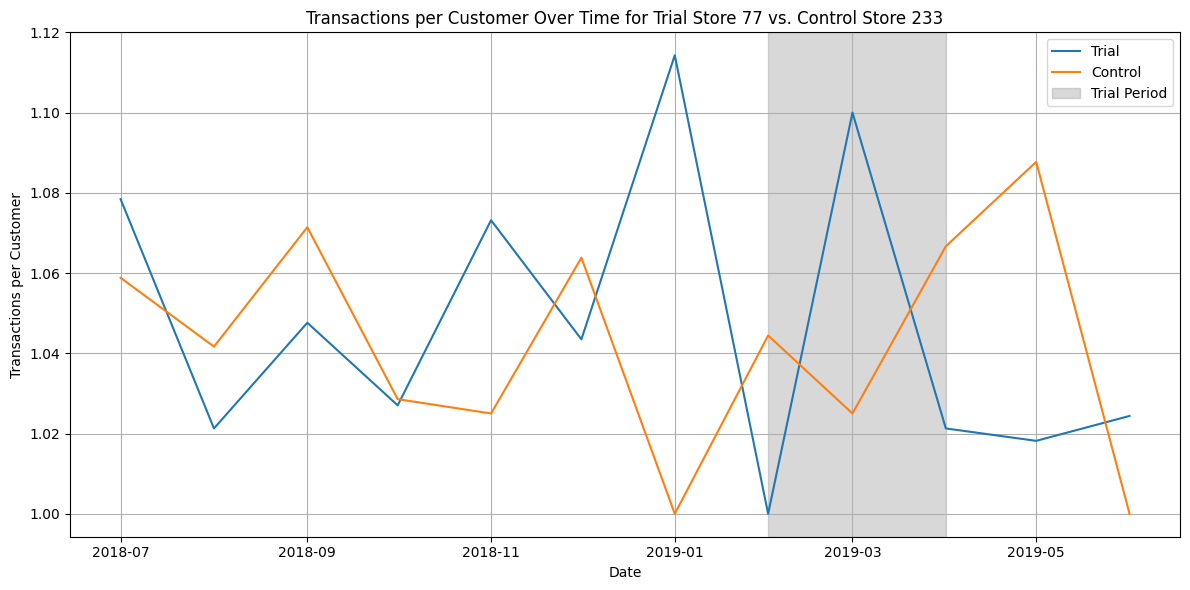

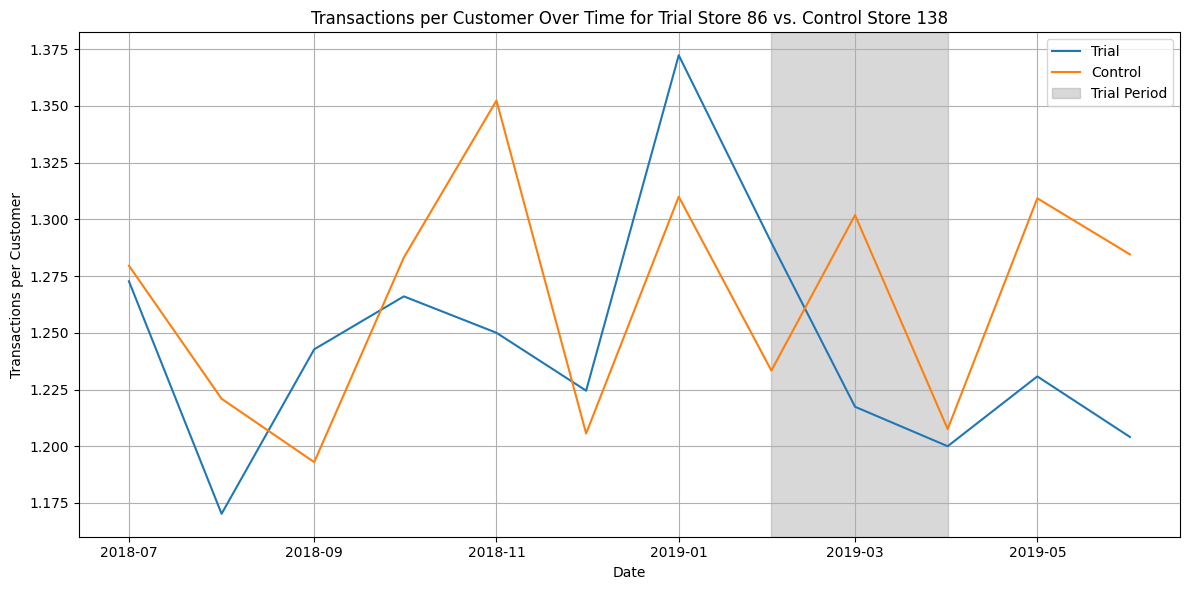

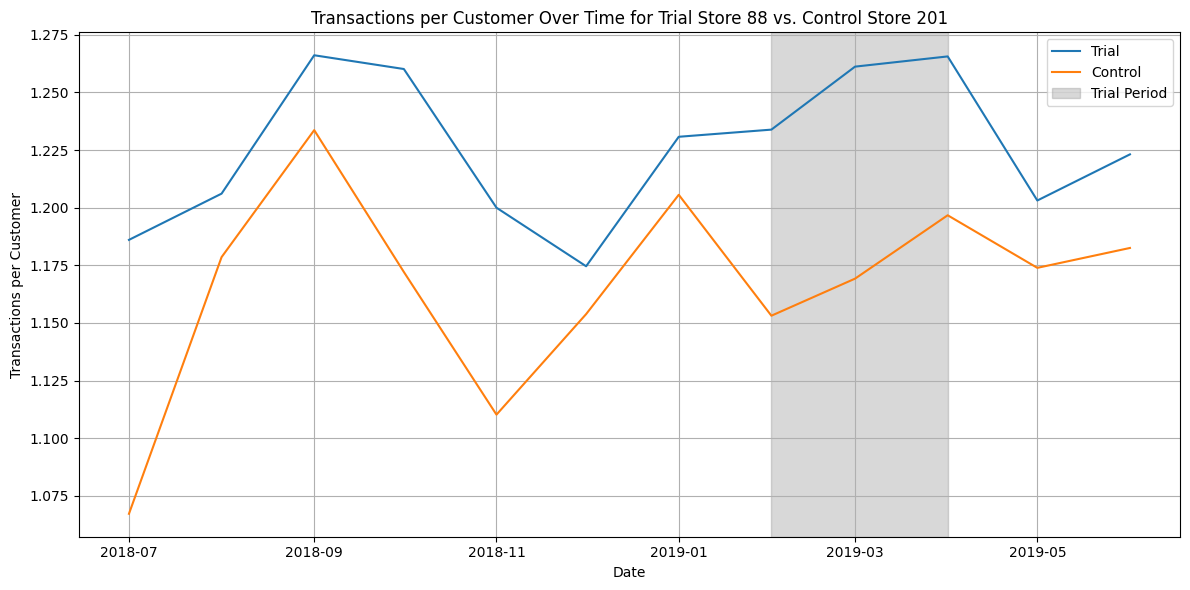

In [ ]:
for trial_store_num, combined_df in trial_control_data.items():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined_df, x='YEARMONTH', y='transactions_per_customer', hue='Store_Type')

    # Add shaded region for trial period
    plt.axvspan(trial_start_date.to_timestamp(), trial_end_date.to_timestamp(), color='grey', alpha=0.3, label='Trial Period')

    plt.title(f'Transactions per Customer Over Time for Trial Store {trial_store_num} vs. Control Store {control_stores_map[trial_store_num]}')
    plt.xlabel('Date')
    plt.ylabel('Transactions per Customer')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


I will calculate the percentage difference in 'transactions_per_customer' between each trial store and its corresponding control store during the trial period, then visualize these differences using a bar chart as per the subtask instructions.



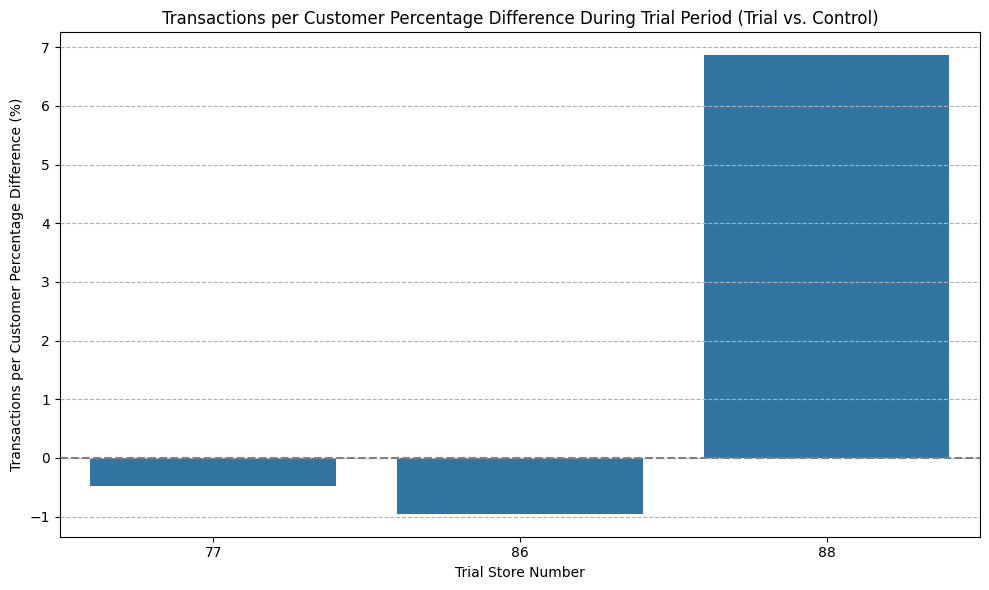

Transactions per customer percentage differences during the trial period:
   Trial_Store  Transactions_per_Customer_Percentage_Difference
0           77                                        -0.473023
1           86                                        -0.952674
2           88                                         6.864949


In [ ]:
tpc_perc_diff = {}

for trial_store_num, combined_df in trial_control_data.items():
    # Filter data for the trial period
    trial_period_data = combined_df[
        (combined_df['YEARMONTH'] >= trial_start_date.to_timestamp()) &
        (combined_df['YEARMONTH'] <= trial_end_date.to_timestamp())
    ]

    # Separate into trial and control transactions_per_customer data
    trial_tpc_data = trial_period_data[trial_period_data['Store_Type'] == 'Trial']
    control_tpc_data = trial_period_data[trial_period_data['Store_Type'] == 'Control']

    # Calculate sum of transactions_per_customer for trial and control during the trial period
    trial_tpc_sum = trial_tpc_data['transactions_per_customer'].sum()
    control_tpc_sum = control_tpc_data['transactions_per_customer'].sum()

    # Calculate percentage difference
    if control_tpc_sum != 0:
        percentage_difference = ((trial_tpc_sum - control_tpc_sum) / control_tpc_sum) * 100
    else:
        percentage_difference = np.nan # Handle division by zero if control tpc are zero

    tpc_perc_diff[trial_store_num] = percentage_difference

# Convert the dictionary to a DataFrame for plotting
tpc_diff_df = pd.DataFrame(tpc_perc_diff.items(), columns=['Trial_Store', 'Transactions_per_Customer_Percentage_Difference'])

# Plotting the transactions per customer percentage difference
plt.figure(figsize=(10, 6))
sns.barplot(x='Trial_Store', y='Transactions_per_Customer_Percentage_Difference', data=tpc_diff_df)
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.title('Transactions per Customer Percentage Difference During Trial Period (Trial vs. Control)')
plt.xlabel('Trial Store Number')
plt.ylabel('Transactions per Customer Percentage Difference (%)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Transactions per customer percentage differences during the trial period:")
print(tpc_diff_df)

## Perform Statistical Significance Testing
Conduct appropriate statistical tests (e.g., independent t-test) to determine if the observed differences in 'total_sales' between the trial store and its control store during the trial period are statistically significant for each trial-control pair. Present the resulting t-statistics and p-values for each test.


In [ ]:
from scipy.stats import ttest_ind

sales_ttest_results = {}

for trial_store_num, combined_df in trial_control_data.items():
    # Filter data for the trial period
    trial_period_data = combined_df[
        (combined_df['YEARMONTH'] >= trial_start_date.to_timestamp()) &
        (combined_df['YEARMONTH'] <= trial_end_date.to_timestamp())
    ]

    # Separate total_sales for trial and control stores
    trial_sales = trial_period_data[trial_period_data['Store_Type'] == 'Trial']['total_sales']
    control_sales = trial_period_data[trial_period_data['Store_Type'] == 'Control']['total_sales']

    # Perform independent samples t-test (Welch's t-test with equal_var=False)
    # Ensure there's enough data for both groups to perform the test
    if len(trial_sales) > 1 and len(control_sales) > 1:
        t_statistic, p_value = ttest_ind(trial_sales, control_sales, equal_var=False)
        sales_ttest_results[trial_store_num] = {'T_Statistic': t_statistic, 'P_Value': p_value}
    else:
        sales_ttest_results[trial_store_num] = {'T_Statistic': np.nan, 'P_Value': np.nan}
        print(f"Warning: Not enough data for t-test for trial store {trial_store_num}.")

# Convert the results to a DataFrame for better readability
sales_ttest_df = pd.DataFrame.from_dict(sales_ttest_results, orient='index')
sales_ttest_df.index.name = 'Trial_Store'
sales_ttest_df.reset_index(inplace=True)

print("Statistical Significance Test Results for Total Sales During Trial Period:")
print(sales_ttest_df)

Statistical Significance Test Results for Total Sales During Trial Period:
   Trial_Store  T_Statistic   P_Value
0           77     2.104355  0.126081
1           86     1.158220  0.311446
2           88     2.480617  0.092682


## Final Task
Compile all generated visualizations and analytical insights into a cohesive narrative, suitable for a short presentation, highlighting the main conclusions and recommendations from the store trial evaluation.


## Summary:
### Data Analysis Key Findings

*   **Data Aggregation**: Monthly data for all stores was aggregated, calculating `total_sales`, `total_customers`, and `total_transactions`, then deriving `transactions_per_customer`.
*   **Control Store Matching**:
    *   Trial Store 77 was matched with Control Store 233.
    *   Trial Store 86 was matched with Control Store 138.
    *   Trial Store 88 was matched with Control Store 201.
    This matching was based on Pearson correlation and magnitude differences of sales, customers, and transactions per customer during the pre-trial period (up to January 2019).
*   **Sales Performance During Trial (Feb-Apr 2019)**:
    *   Trial Store 77 showed a significant increase of 29.13% in total sales compared to its control.
    *   Trial Store 86 showed a moderate increase of 10.49% in total sales compared to its control.
    *   Trial Store 88 showed a moderate increase of 14.31% in total sales compared to its control.
*   **Customer Performance During Trial (Feb-Apr 2019)**:
    *   Trial Store 77 experienced a substantial increase of 23.48% in total customers compared to its control.
    *   Trial Store 86 had a moderate increase of 8.28% in total customers compared to its control.
    *   Trial Store 88 saw a moderate increase of 6.34% in total customers compared to its control.
*   **Transactions per Customer Performance During Trial (Feb-Apr 2019)**:
    *   Trial Stores 77 and 86 showed slight decreases of -0.47% and -0.95% respectively in transactions per customer compared to their controls.
    *   Trial Store 88 demonstrated a noticeable increase of 6.86% in transactions per customer compared to its control.
*   **Statistical Significance of Sales (p-values from independent t-test)**:
    *   Trial Store 77: p-value of 0.126 (not significant at $\alpha=0.05$).
    *   Trial Store 86: p-value of 0.311 (not significant at $\alpha=0.05$).
    *   Trial Store 88: p-value of 0.093 (not significant at $\alpha=0.05$).

### Insights or Next Steps

*   **Validate Store 77's Performance**: Despite the lack of statistical significance, the large percentage uplift in sales (29.13%) and customers (23.48%) for Store 77 warrants further investigation. Consider extending the trial or conducting A/B testing with a larger sample to achieve statistical power and confirm the drivers of customer increase.
*   **Refine Strategy for Store 86**: The modest, non-significant uplift in Store 86 suggests that the trial strategy might need refinement. Local factors, marketing efforts, or operational aspects should be reviewed for potential adjustments before considering wider implementation.
*   **Investigate Store 88's Balanced Growth**: Store 88 showed promising growth in both customer count and transactions per customer (6.86%). Further qualitative research or A/B testing focusing on the specific conditions of Store 88 could help identify successful elements that increase both metrics.
